# 01 EDA

# Conflict Escalation Forecasting

**District-level 14-day conflict escalation risk — South Asia, Sudan & South Sudan**

Data: [ACLED](https://acleddata.com) (acleddata.com), weekly aggregated admin-1 export.
All logic is imported from `src/` — this notebook only demonstrates the pipeline.

> **Reproducibility:** every stage is deterministic (fixed seed 42, chronological
> split, no shuffle). Running the full pipeline:
> `for s in ingest features labels split train compare explain visualize; do python run_pipeline.py --stage $s; done`


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
_root = Path.cwd()
if not (_root / 'config.py').is_file():
    _root = _root.parent  # kernel cwd is notebooks/
sys.path.insert(0, str(_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
def show_inline():
    # src modules may force the Agg backend at import; re-assert
    # the inline backend right before displaying so plots embed.
    get_ipython().run_line_magic('matplotlib', 'inline')
    plt.show()
import config


## 1. Load the validated dataset

In [2]:
clean = pd.read_parquet(config.DATA_PROCESSED_DIR / f'{config.CLEANED_EVENTS_FILE}.parquet')
print('cleaned_events:', clean.shape)
print('date range:', clean['event_date'].min().date(), '->', clean['event_date'].max().date())
print('countries:', clean['country'].nunique())
print('geo units:', clean['geo_unit'].nunique())
clean.head()

cleaned_events: (127052, 14)
date range: 2016-12-31 -> 2026-07-25
countries: 6
geo units: 124


,event_date,region,country,admin1,event_type,sub_event_type,events,fatalities,population_exposure,disorder_type,latitude,longitude,geo_unit,event_id
0,2016-12-31,Caucasus and Central Asia,Afghanistan,Badakhshan,Battles,Armed clash,6,15,"113,469",Political violence,36.966,73.342,Badakhshan,2016-12-31|Afghanistan|Badakhshan|Battles|Arme...
1,2016-12-31,Caucasus and Central Asia,Afghanistan,Badghis,Battles,Armed clash,7,93,"17,594",Political violence,35.257,63.581,Badghis,2016-12-31|Afghanistan|Badghis|Battles|Armed c...
2,2016-12-31,Caucasus and Central Asia,Afghanistan,Baghlan,Battles,Armed clash,4,2,"95,653",Political violence,35.790,69.109,Baghlan,2016-12-31|Afghanistan|Baghlan|Battles|Armed c...
3,2016-12-31,Caucasus and Central Asia,Afghanistan,Baghlan,Violence against civilians,Attack,1,7,0,Political violence,35.790,69.109,Baghlan,2016-12-31|Afghanistan|Baghlan|Violence agains...
4,2016-12-31,Caucasus and Central Asia,Afghanistan,Balkh,Explosions/Remote violence,Remote explosive/landmine/IED,1,2,"12,869",Political violence,36.529,66.912,Balkh,2016-12-31|Afghanistan|Balkh|Explosions/Remote...


## 2. Country coverage

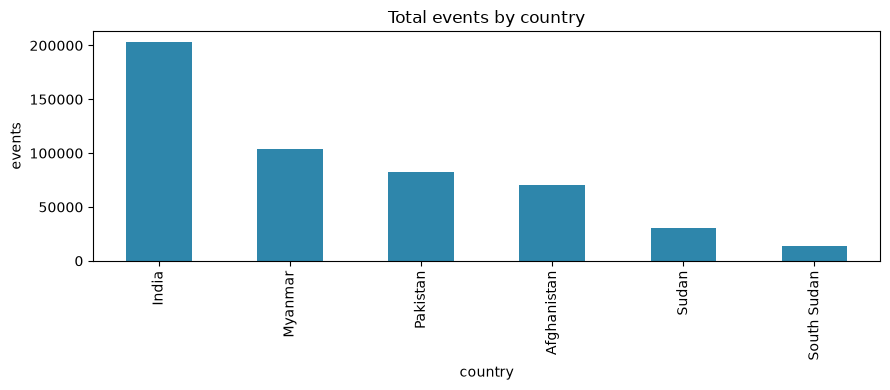

country
India          202942
Myanmar        104219
Pakistan        82636
Afghanistan     70066
Sudan           30658
South Sudan     13990
Name: events, dtype: int64

In [3]:
country_counts = clean.groupby('country')['events'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
country_counts.plot.bar(ax=ax, color='#2E86AB')
ax.set_title('Total events by country')
ax.set_ylabel('events')
plt.tight_layout()
show_inline()
country_counts

## 3. Event-type mix

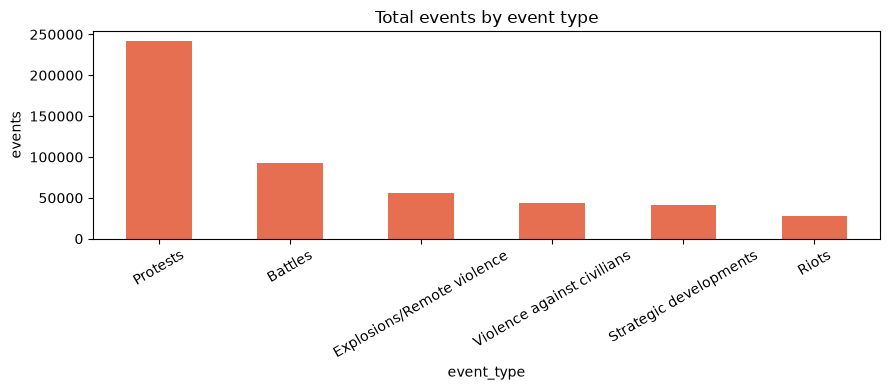

event_type
Protests                      241654
Battles                        92796
Explosions/Remote violence     56342
Violence against civilians     43639
Strategic developments         41836
Riots                          28244
Name: events, dtype: int64

In [4]:
etype = clean.groupby('event_type')['events'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
etype.plot.bar(ax=ax, color='#E76F51')
ax.set_title('Total events by event type')
ax.set_ylabel('events')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
show_inline()
etype

## 4. Top hotspots (by total events)

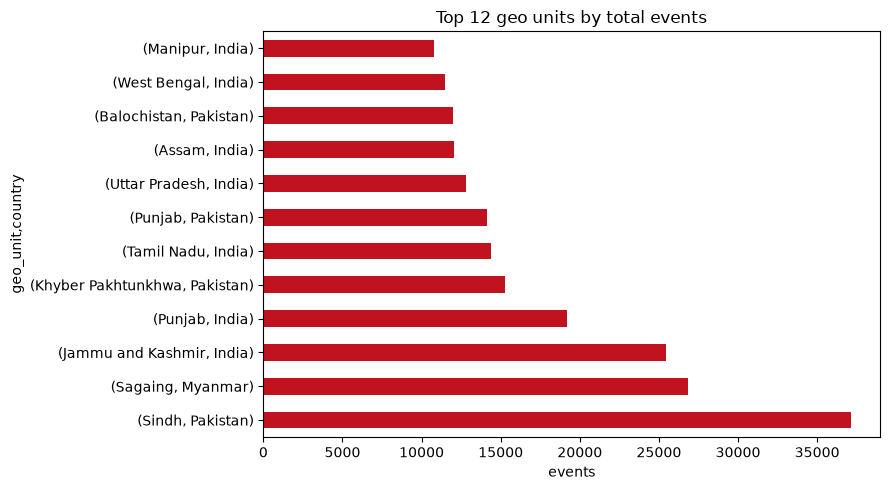

geo_unit            country 
Sindh               Pakistan    37117
Sagaing             Myanmar     26847
Jammu and Kashmir   India       25434
Punjab              India       19222
Khyber Pakhtunkhwa  Pakistan    15264
Tamil Nadu          India       14402
Punjab              Pakistan    14117
Uttar Pradesh       India       12837
Assam               India       12062
Balochistan         Pakistan    12002
West Bengal         India       11459
Manipur             India       10807
Name: events, dtype: int64

In [5]:
hot = clean.groupby(['geo_unit', 'country'])['events'].sum().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(9, 5))
hot.plot.barh(ax=ax, color='#C1121F')
ax.set_title('Top 12 geo units by total events')
ax.set_xlabel('events')
plt.tight_layout()
show_inline()
hot

## 5. Fatalities over time (monthly)

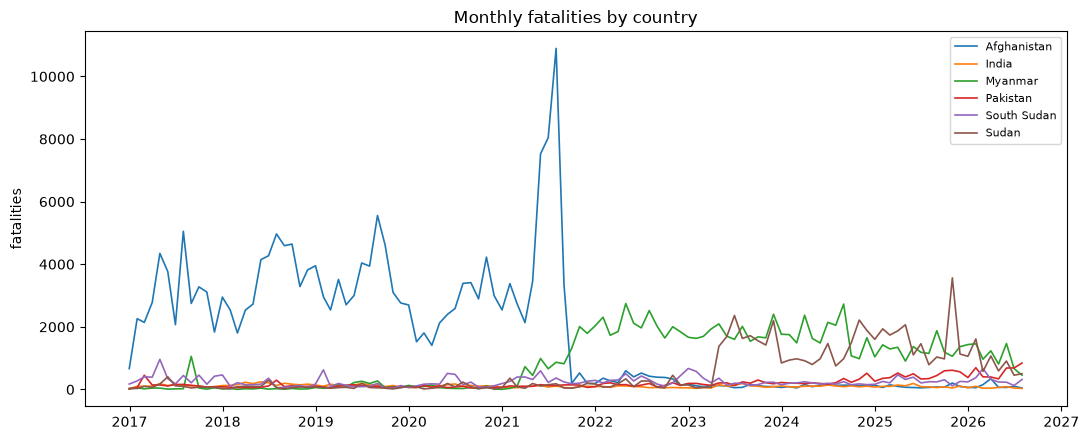

In [6]:
monthly = clean.set_index('event_date').groupby('country').resample('ME')['fatalities'].sum().reset_index()
fig, ax = plt.subplots(figsize=(11, 4.5))
for country, g in monthly.groupby('country'):
    ax.plot(g['event_date'], g['fatalities'], label=country, linewidth=1.2)
ax.set_title('Monthly fatalities by country')
ax.set_ylabel('fatalities')
ax.legend(fontsize=8)
plt.tight_layout()
show_inline()

## 6. District master

In [7]:
master = pd.read_parquet(config.DATA_PROCESSED_DIR / f'{config.DISTRICT_MASTER_FILE}.parquet')
print('district_master:', master.shape)
master.head()

district_master: (124, 9)


,geo_unit,admin1,country,latitude,longitude,total_events,n_rows,first_date,last_date
0,Badakhshan,Badakhshan,Afghanistan,36.966,73.342,1491,785,2016-12-31,2026-07-25
1,Badghis,Badghis,Afghanistan,35.257,63.581,1761,666,2016-12-31,2026-07-04
2,Baghlan,Baghlan,Afghanistan,35.790,69.109,2083,936,2016-12-31,2026-07-25
3,Balkh,Balkh,Afghanistan,36.529,66.912,2628,960,2016-12-31,2026-07-11
4,Bamyan,Bamyan,Afghanistan,34.695,67.338,140,121,2017-02-25,2026-06-20


## Summary
- **127,052 validated rows**, 124 geo units, 6 countries (2016-12-31 → 2026-07-25).
- India, Myanmar and Afghanistan dominate event counts; Pakistan and Sudan carry high fatality loads.
- Top hotspots include **Sindh, Punjab, Khyber Pakhtunkhwa, Balochistan, Kabul**.